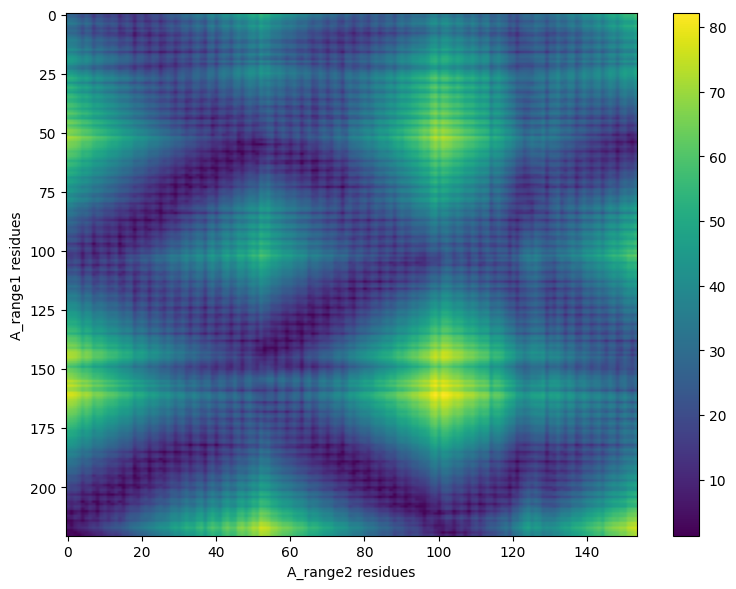

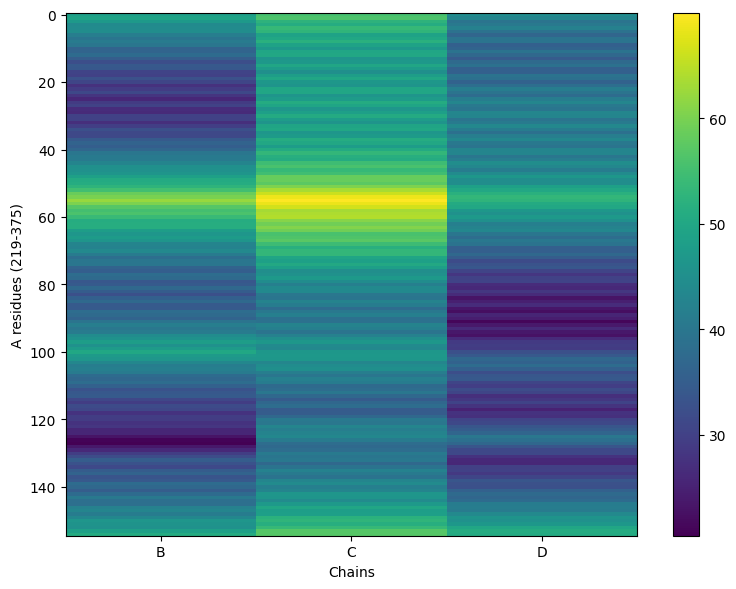

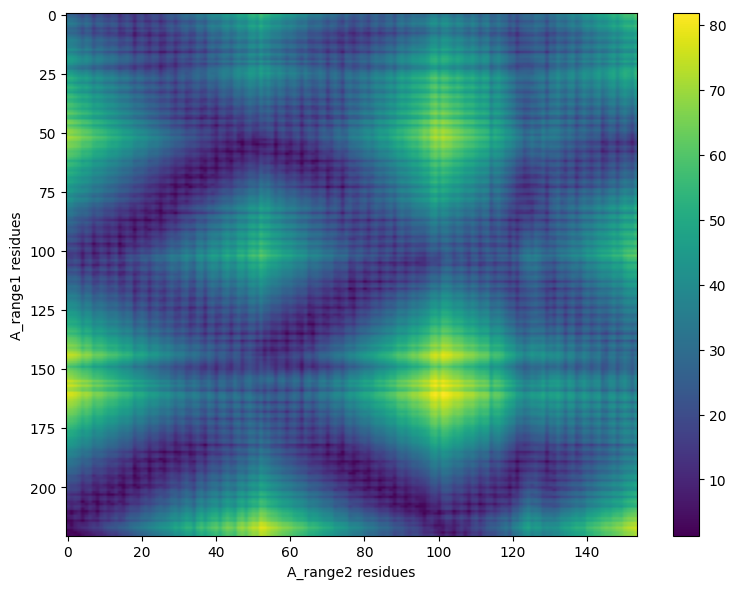

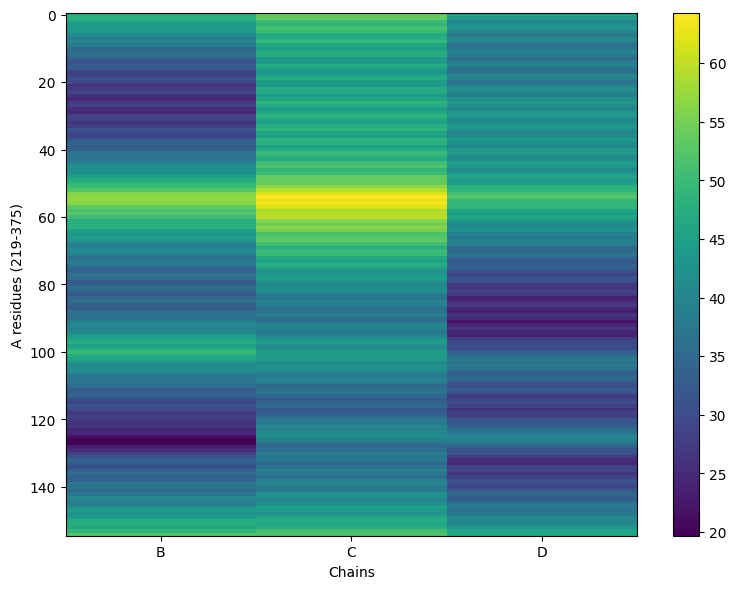

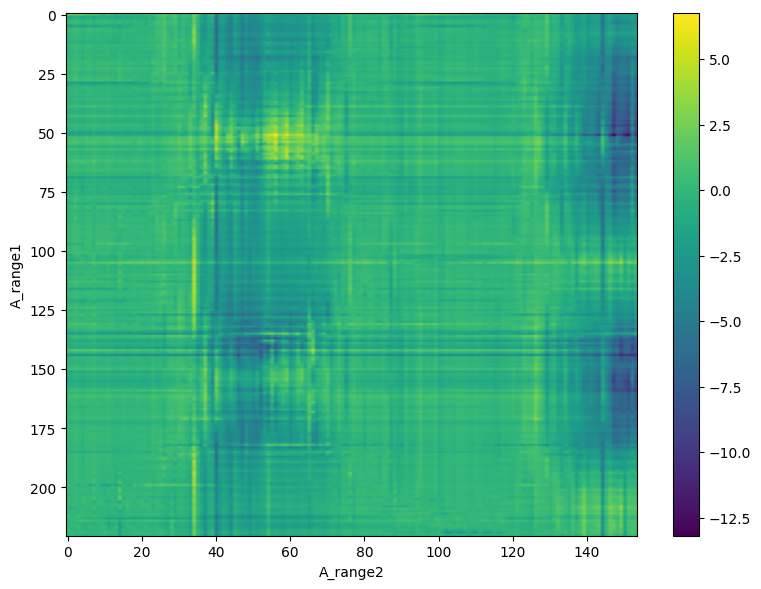

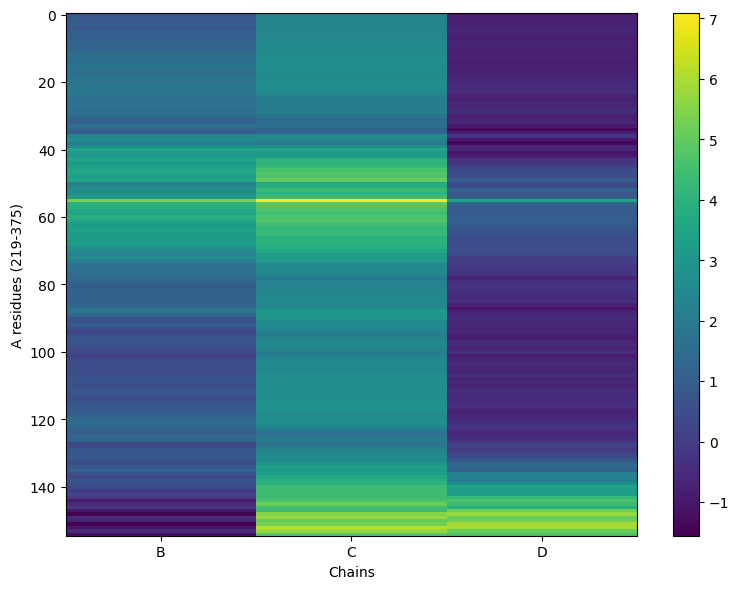

In [ ]:
from Bio import PDB
import numpy as np
import matplotlib.pyplot as plt
import re

# Helper to extract integer from residue ID string like 'A_ASP219' or 'A_ASP_219'
def _extract_resnum(res_str):
    digits = ''.join(ch for ch in res_str if ch.isdigit())
    return int(digits) if digits else None


def calculate_residue_pair_distances(pdb_file, range1=(1, 219), range2=(219, 375)):

    parser = PDB.PDBParser(QUIET=True)
    structure = parser.get_structure('protein', pdb_file)

    residues1 = []
    residues2 = []

    for model in structure:
        for chain in model:
            if chain.id != 'A':
                continue
            for residue in chain:
                try:
                    res_id = residue.get_id()[1]
                except Exception:
                    continue
                if range1[0] <= res_id <= range1[1]:
                    residues1.append(residue)
                elif range2[0] <= res_id <= range2[1]:
                    residues2.append(residue)

    n1 = len(residues1)
    n2 = len(residues2)
    distances = np.full((n1, n2), np.nan)
    residue_pairs = []

    for i, r1 in enumerate(residues1):
        atoms1 = list(r1.get_atoms())
        for j, r2 in enumerate(residues2):
            atoms2 = list(r2.get_atoms())
            min_d = float('inf')
            for a1 in atoms1:
                for a2 in atoms2:
                    try:
                        d = a1 - a2
                    except Exception:
                        continue
                    if d < min_d:
                        min_d = d
            if min_d == float('inf'):
                min_d = float('nan')
            distances[i, j] = min_d
            residue_pairs.append({
                'res1': f"A_{r1.get_resname()}{r1.get_id()[1]}",
                'res2': f"A_{r2.get_resname()}{r2.get_id()[1]}",
                'distance': min_d
            })

    return distances, residue_pairs, residues1, residues2


def calculate_ca_to_chain_centroids(pdb_file, a_range=(219, 375), centroid_region=(1, 460)):

    parser = PDB.PDBParser(QUIET=True)
    structure = parser.get_structure('protein', pdb_file)

    residues_A = []
    centroids = {'B': None, 'C': None, 'D': None}
    cstart, cend = centroid_region

    for model in structure:
        for chain in model:
            if chain.id == 'A':
                for residue in chain:
                    res_id = residue.get_id()[1]
                    if a_range[0] <= res_id <= a_range[1] and 'CA' in residue:
                        residues_A.append(residue)
            elif chain.id in ['B', 'C', 'D']:
                cas = []
                for residue in chain:
                    res_id = residue.get_id()[1]
                    if cstart <= res_id <= cend and 'CA' in residue:
                        cas.append(residue['CA'].get_vector().get_array())
                if len(cas) > 0:
                    centroids[chain.id] = np.mean(np.vstack(cas), axis=0)
                else:
                    centroids[chain.id] = None

    n_A = len(residues_A)
    chains_order = ['B', 'C', 'D']
    distances = np.full((n_A, len(chains_order)), np.nan)
    residue_pairs = []

    for i, resA in enumerate(residues_A):
        ca_pos = resA['CA'].get_vector().get_array()
        for j, ch in enumerate(chains_order):
            centroid = centroids[ch]
            if centroid is None:
                d = float('nan')
            else:
                d = np.linalg.norm(ca_pos - centroid)
            distances[i, j] = d
            residue_pairs.append({
                'res1': f"A_{resA.get_resname()}{resA.get_id()[1]}",
                'res2': f"{ch}_centroid_{centroid_region[0]}-{centroid_region[1]}",
                'distance': d
            })

    return distances, residue_pairs, residues_A


def calculate_distance_difference(m1, m2, atom_pairs):

    a1 = np.array(m1)
    a2 = np.array(m2)
    if a1.shape != a2.shape:
        raise ValueError(f"{a1.shape} vs {a2.shape}")
    diff = a1 - a2
    nrows, ncols = diff.shape
    diff_pairs = []
    for i in range(nrows):
        for j in range(ncols):
            idx = i * ncols + j
            pair = atom_pairs[idx]
            diff_pairs.append({
                'atom1': pair['res1'],
                'atom2': pair['res2'],
                'diff': diff[i, j]
            })
    diff_pairs.sort(key=lambda x: abs(x['diff']) if not np.isnan(x['diff']) else -np.inf, reverse=True)
    return diff, diff_pairs


def plot_matrix(mat, outfile, xlabel=None, ylabel=None, xlabels=None):
    plt.figure(figsize=(8, 6))
    im = plt.imshow(mat, cmap='viridis', aspect='auto')
    plt.colorbar(im)
    if xlabels is not None:
        plt.xticks(ticks=np.arange(len(xlabels)), labels=xlabels)
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    plt.tight_layout()
    plt.savefig(outfile)


def extract_significant_changes(diff_pairs, atom_pairs, distance_cutoff, output_file="significant_changes.txt", Achainin=True):
    significant_changes = []
    processed_pairs = set()

    for idx, pair in enumerate(diff_pairs):
        if np.isnan(pair['diff']):
            continue
        if not pair['atom1'].startswith('A'):
            continue
        resnum = _extract_resnum(pair['atom1'])
        if resnum is None:
            continue

        pair_id = tuple(sorted([pair['atom1'], pair['atom2']]))
        if pair_id in processed_pairs:
            continue

        distance1 = atom_pairs[idx]['distance']
        distance2 = distance1 - pair['diff']

        if Achainin:
            if distance1 > 20 and distance2 > 20:
                continue

        if abs(pair['diff']) > distance_cutoff:
            significant_changes.append({
                'atom1': pair_id[0],
                'atom2': pair_id[1],
                'diff': pair['diff'],
                'distance1': distance1,
                'distance2': distance2
            })
            processed_pairs.add(pair_id)

    significant_changes.sort(key=lambda x: abs(x['diff']), reverse=True)
    with open(output_file, 'w') as f:
        f.write(f"Distance differences larger than {distance_cutoff} Å:\n")
        f.write("Atom1\tAtom2\tDifference(Å)\tDistance1(Å)\tDistance2(Å)\n")
        for change in significant_changes:
            f.write(f"{change['atom1']}\t{change['atom2']}\t{change['diff']:.2f}\t{change['distance1']:.2f}\t{change['distance2']:.2f}\n")

    return significant_changes


def calculate_dihedrals(pdb_file, res_range=None):
    parser = PDB.PDBParser(QUIET=True)
    structure = parser.get_structure('protein', pdb_file)
    def is_in_range(residue):
        if res_range is None:
            return True
        res_id = residue.get_id()[1]
        return res_range[0] <= res_id <= res_range[1]
    ppb = PDB.PPBuilder()
    dihedrals = []
    def calc_dihedral(p1, p2, p3, p4):
        return PDB.calc_dihedral(p1, p2, p3, p4)
    chi_atoms = {
        'ARG': [
            ['N', 'CA', 'CB', 'CG'],  # chi1
            ['CA', 'CB', 'CG', 'CD'],  # chi2
            ['CB', 'CG', 'CD', 'NE'],  # chi3
            ['CG', 'CD', 'NE', 'CZ']   # chi4
        ],
        'LYS': [
            ['N', 'CA', 'CB', 'CG'],
            ['CA', 'CB', 'CG', 'CD'],
            ['CB', 'CG', 'CD', 'CE'],
            ['CG', 'CD', 'CE', 'NZ']
        ],
        'MET': [
            ['N', 'CA', 'CB', 'CG'],
            ['CA', 'CB', 'CG', 'SD'],
            ['CB', 'CG', 'SD', 'CE']
        ],
        'GLU': [
            ['N', 'CA', 'CB', 'CG'],
            ['CA', 'CB', 'CG', 'CD'],
            ['CB', 'CG', 'CD', 'OE1']
        ],
        'GLN': [
            ['N', 'CA', 'CB', 'CG'],
            ['CA', 'CB', 'CG', 'CD'],
            ['CB', 'CG', 'CD', 'OE1']
        ],
        'ILE': [
            ['N', 'CA', 'CB', 'CG1'],
            ['CA', 'CB', 'CG1', 'CD1']
        ],
        'LEU': [
            ['N', 'CA', 'CB', 'CG'],
            ['CA', 'CB', 'CG', 'CD1']
        ],
        'HSD': [
            ['N', 'CA', 'CB', 'CG'],
            ['CA', 'CB', 'CG', 'ND1']
        ],
        'ASP': [
            ['N', 'CA', 'CB', 'CG'],
            ['CA', 'CB', 'CG', 'OD1']
        ],
        'ASN': [
            ['N', 'CA', 'CB', 'CG'],
            ['CA', 'CB', 'CG', 'OD1']
        ],
        'PHE': [
            ['N', 'CA', 'CB', 'CG'],
            ['CA', 'CB', 'CG', 'CD1']
        ],
        'TYR': [
            ['N', 'CA', 'CB', 'CG'],
            ['CA', 'CB', 'CG', 'CD1']
        ],
        'TRP': [
            ['N', 'CA', 'CB', 'CG'],
            ['CA', 'CB', 'CG', 'CD1']
        ],
        'PRO': [
            ['N', 'CA', 'CB', 'CG'],
            ['CA', 'CB', 'CG', 'CD']
        ],
        'CYS': [['N', 'CA', 'CB', 'SG']],
        'THR': [['N', 'CA', 'CB', 'OG1']],
        'SER': [['N', 'CA', 'CB', 'OG']],
        'VAL': [['N', 'CA', 'CB', 'CG1']]
    }
    for pp in ppb.build_peptides(structure):
        if pp[0].get_parent().id != 'A':
            continue
        phi_psi = pp.get_phi_psi_list()
        for i, residue in enumerate(pp):
            if not is_in_range(residue):
                continue
            phi, psi = phi_psi[i]
            chain_id = residue.get_parent().id
            res_name = residue.get_resname()
            res_id = residue.get_id()[1]
            omega_deg = float('nan')
            if i > 0 and is_in_range(pp[i-1]):
                try:
                    prev_c = pp[i-1]['C'].get_vector()
                    curr_n = residue['N'].get_vector()
                    curr_ca = residue['CA'].get_vector()
                    curr_c = residue['C'].get_vector()
                    omega = calc_dihedral(prev_c, curr_n, curr_ca, curr_c)
                    omega_deg = np.degrees(omega)
                except KeyError:
                    pass
            phi_deg = np.degrees(phi) if phi is not None else float('nan')
            psi_deg = np.degrees(psi) if psi is not None else float('nan')
            chi_angles = [float('nan')] * 4
            if res_name in chi_atoms:
                for chi_idx, atoms in enumerate(chi_atoms[res_name]):
                    try:
                        if all(atom in residue for atom in atoms):
                            vectors = [residue[atom].get_vector() for atom in atoms]
                            chi = calc_dihedral(*vectors)
                            chi_angles[chi_idx] = np.degrees(chi)
                    except KeyError:
                        continue
            dihedral_info = {
                'residue': f"{chain_id}_{res_name}{res_id}",
                'omega': omega_deg,
                'phi': phi_deg,
                'psi': psi_deg,
                'chi1': chi_angles[0],
                'chi2': chi_angles[1],
                'chi3': chi_angles[2],
                'chi4': chi_angles[3]
            }
            dihedrals.append(dihedral_info)
    return dihedrals


def calculate_dihedral_differences(dihedrals1, dihedrals2):
    dihedral_diffs = []
    if len(dihedrals1) != len(dihedrals2):
        return dihedral_diffs
    for d1, d2 in zip(dihedrals1, dihedrals2):
        if d1['residue'] != d2['residue']:
            continue
        diff_info = {'residue': d1['residue']}
        for angle in ['omega', 'phi', 'psi', 'chi1', 'chi2', 'chi3', 'chi4']:
            if not (np.isnan(d1[angle]) or np.isnan(d2[angle])):
                diff = np.abs((d1[angle] - d2[angle] + 180) % 360 - 180)
                diff_info[f'{angle}_diff'] = diff
            else:
                diff_info[f'{angle}_diff'] = float('nan')
        dihedral_diffs.append(diff_info)
    return dihedral_diffs


def extract_significant_dihedral_changes(dihedral_diffs, angle_cutoff, output_file="significant_dihedral_changes.txt"):
    significant_changes = []
    for diff in dihedral_diffs:
        significant_angles = {}
        for angle in ['omega', 'phi', 'psi', 'chi1', 'chi2', 'chi3', 'chi4']:
            if not np.isnan(diff[f'{angle}_diff']) and abs(diff[f'{angle}_diff']) > angle_cutoff:
                significant_angles[angle] = diff[f'{angle}_diff']
        if significant_angles:
            change_info = {
                'residue': diff['residue'],
                'angles': significant_angles
            }
            significant_changes.append(change_info)
    with open(output_file, 'w') as f:
        f.write(f"Dihedral angle differences larger than {angle_cutoff} degrees:\n")
        f.write("Residue\tAngle\tDifference(degrees)\n")
        for change in significant_changes:
            for angle, diff_value in change['angles'].items():
                f.write(f"{change['residue']}\t{angle}\t{diff_value:.2f}\n")
    return significant_changes


def main():

    range1 = (1, 221)
    range2 = (221, 375)
    centroid_region = (1, 460)
    dihedral_range = (221, 375)

    open_pdb = 'open.pdb'
    open_cross_dist, open_cross_pairs, open_r1, open_r2 = calculate_residue_pair_distances(open_pdb, range1, range2)
    plot_matrix(open_cross_dist, 'open_A1-219_vs_219-375.png', xlabel='A_range2 residues', ylabel='A_range1 residues')

    open_ca_cent, open_ca_pairs, open_ca_res = calculate_ca_to_chain_centroids(open_pdb, a_range=range2, centroid_region=centroid_region)
    plot_matrix(open_ca_cent, 'open_A219-375_vs_BCDcentroids.png', xlabels=['B','C','D'], xlabel='Chains', ylabel='A residues (219-375)')

    close_pdb = 'close.pdb'
    close_cross_dist, close_cross_pairs, close_r1, close_r2 = calculate_residue_pair_distances(close_pdb, range1, range2)
    plot_matrix(close_cross_dist, 'close_A1-219_vs_219-375.png', xlabel='A_range2 residues', ylabel='A_range1 residues')

    close_ca_cent, close_ca_pairs, close_ca_res = calculate_ca_to_chain_centroids(close_pdb, a_range=range2, centroid_region=centroid_region)
    plot_matrix(close_ca_cent, 'close_A219-375_vs_BCDcentroids.png', xlabels=['B','C','D'], xlabel='Chains', ylabel='A residues (219-375)')

    try:
        cross_diff_matrix, cross_diff_pairs = calculate_distance_difference(open_cross_dist, close_cross_dist, open_cross_pairs)
        plot_matrix(cross_diff_matrix, 'open_minus_close_cross.png', xlabel='A_range2', ylabel='A_range1')
    except ValueError as e:
        print('Cross-distance matrices shape mismatch:', e)
        cross_diff_pairs = []

    try:
        ca_diff_matrix, ca_diff_pairs = calculate_distance_difference(open_ca_cent, close_ca_cent, open_ca_pairs)
        plot_matrix(ca_diff_matrix, 'open_minus_close_ca_centroids.png', xlabels=['B','C','D'], xlabel='Chains', ylabel='A residues (219-375)')
    except ValueError as e:
        print('CA-centroid matrices shape mismatch:', e)
        ca_diff_pairs = []

    distance_cutoff = 5
    if cross_diff_pairs:
        significant_cross = extract_significant_changes(cross_diff_pairs, open_cross_pairs, distance_cutoff, 'significant_cross_changes.txt')
    else:
        significant_cross = []
    if ca_diff_pairs:
        significant_ca = extract_significant_changes(ca_diff_pairs, open_ca_pairs, distance_cutoff, 'significant_ca_centroid_changes.txt',Achainin=False)
    else:
        significant_ca = []

    open_dihedrals = calculate_dihedrals(open_pdb, dihedral_range)
    close_dihedrals = calculate_dihedrals(close_pdb, dihedral_range)
    dihedral_diffs = calculate_dihedral_differences(open_dihedrals, close_dihedrals)
    angle_cutoff = 10
    significant_dihedral_changes = extract_significant_dihedral_changes(dihedral_diffs, angle_cutoff, 'significant_dihedral_changes.txt')

if __name__ == '__main__':
    main()
